# TCLab CLP PID FF

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tclab
import time
from datetime import datetime
import os

from IPython.display import display, clear_output

from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_Lab
from package_Lab import LL_RT, PID_RT,IMC_tuning
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode


from importlib import reload
package_Lab=reload(package_Lab)

In [15]:

TSim = 3000
Ts = 0.5
N = int(TSim/Ts) + 1

MVMAx = 100 
MVMin = 0

MV0 = 50
DV0 = 50
PV0 = 54 #point de fonctionnement, trouver en faisant 50 50 sur le systeme

#Paramètres 

#Second ordre
Kp = 0.3768941279826313
T1p = TLead1 = 187.1409297022807
T2p = TLead2 = 10.452990644869
theta_p =  13.137983829128451 

#Premier ordre
Kp_FOPDTOPT =  0.37720311160467174
T_FOPDTOPT =  188.30559411020332
theta_FOPDTOPT = 23.189177284051183

#Perturbation
Kd = 0.3241048096246215
T1d = Tlag1 = 221.16602071422838 
T2d = Tlag2 = 16.741635805529068
theta_d = 5.453465939559135


#C
gamma = 0.9

Ti_IMC,Td_IMC,Kc_IMC = IMC_tuning(Kp, T1p,T2p,theta_p,gamma)
alpha_IMC = 0.9
print('Kc = ',Kc_IMC)
print('Ti = ',Ti_IMC)
print('Td = ',Td_IMC)


Kc =  2.887503384440852
Ti =  197.5939203471497
Td =  9.90001303690539


# Scénarios

In [ ]:
# #Scénario OLP sans FF
# SPPath = {0: PV0,TSim: PV0} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: True, TSim: True} 
# MVMANPath = {0: MV0, TSim: MV0}
# StateFF = False
# ManFF =  False

# #Scénario OLP + FF
# SPPath = {0: PV0,TSim: PV0} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: True, TSim: True} 
# MVMANPath = {0: MV0, TSim: MV0}
# StateFF = True
# ManFF =  True

# #Scénario CLP sans FF
SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
MANPath = {0: True, 400: False, TSim: False} 
MVMANPath = {0: MV0+10, TSim: MV0+10}
StateFF = False
ManFF =  False

#Scénario CLP + FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = True
# ManFF =  True



In [17]:
t = []
PV= []
SP = []
MV = []
DV = []
MV_PID = []
MVI = []
MVP = []
MVD = []

MAN = []
MVMAN = []


E = []
PV1 = []


#FF
MANFF = []
MVFF = []
MVFFDelay = []

#P(s) Parameters

MVDelayp = []
PV1p = []
PV2p = []

#D(s) Parameters
MVDelayd = []
PV1d = []
PV2d = []


lab = tclab.TCLab()

now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")

  

TCLab version 2.1.2_DBR
--- Serial Ports ---


RuntimeError: No Arduino device found.

(0.0, 3000.0)

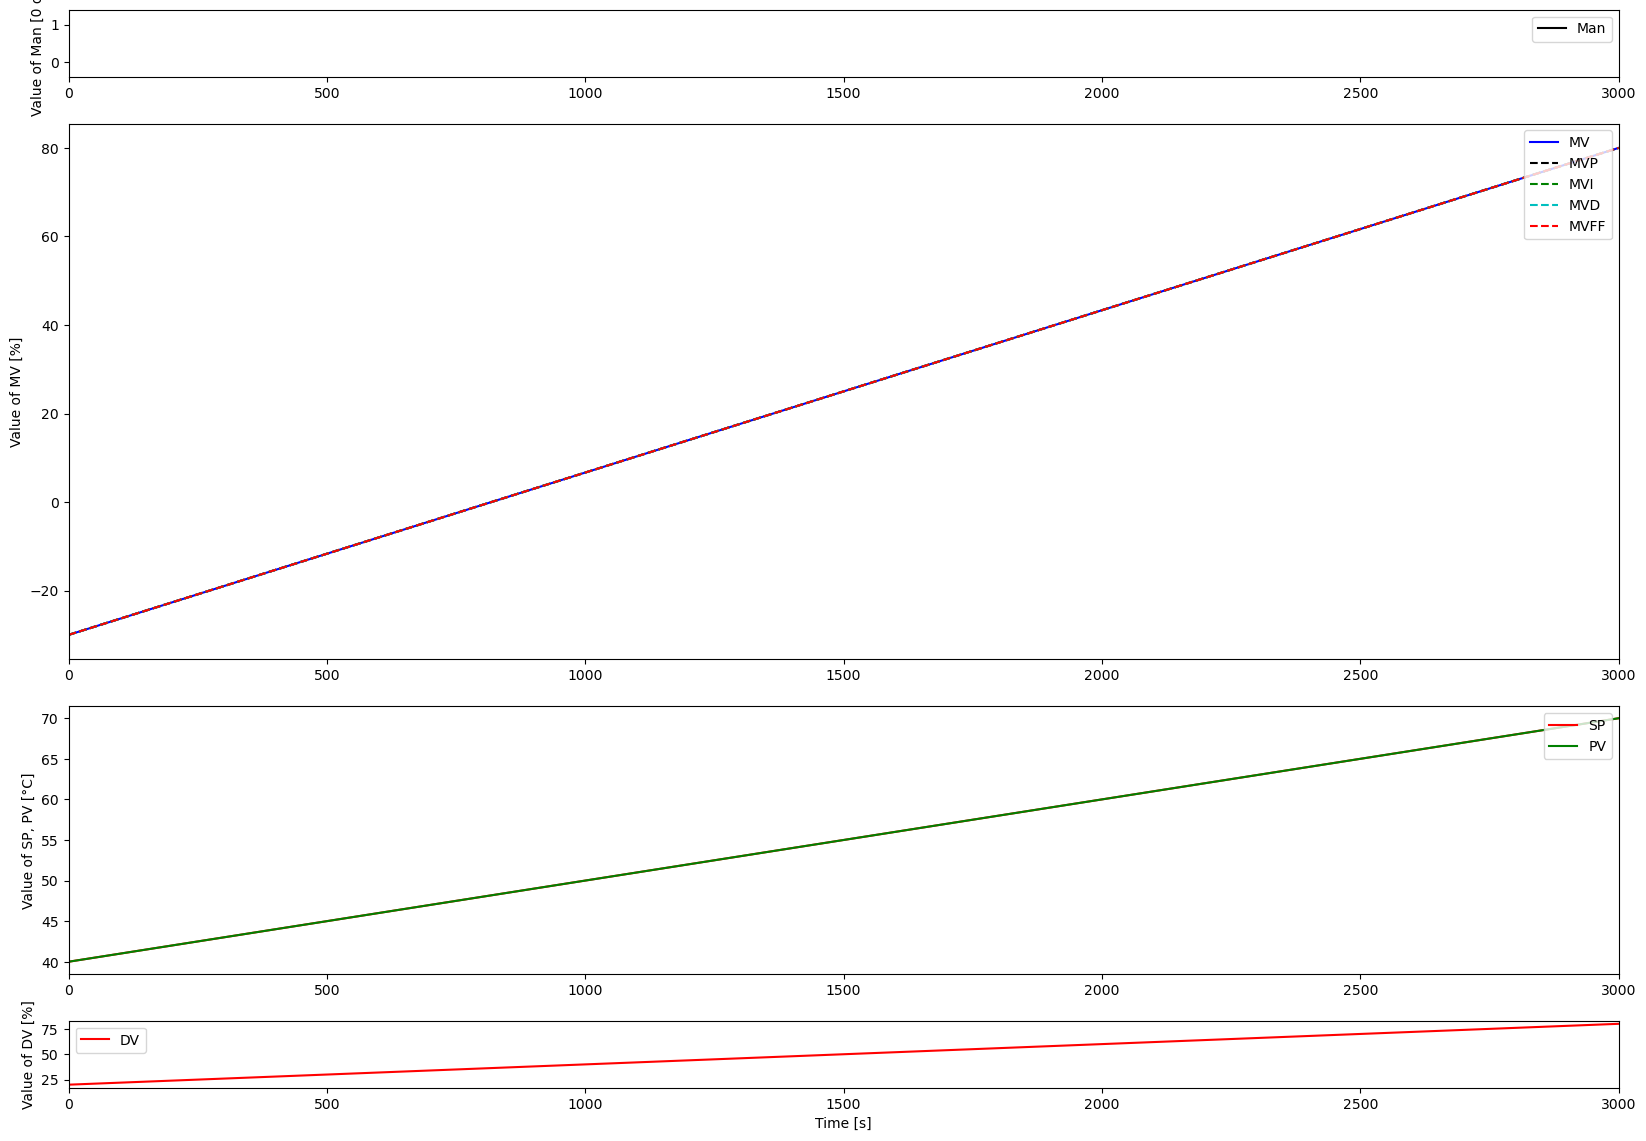

In [ ]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(4, 1,figsize=(20, 14), gridspec_kw={'height_ratios': [1, 8, 4,1]})
fig.suptitle('Closed-loop responses with PID controller and feedforward')

#Manual Mode
MAN_int = [1 if m else 0 for m in MAN]
l1, = ax1.plot(t, MAN_int, 'k-', label='Man')
ax1.set_ylabel('Value of Man [0 or 1]')
ax1.set_ylim([-0.4, 1.4])
ax1.legend(loc='upper right')
ax1.set_xlim([0, TSim])

#MV
l2, = ax2.plot([0,TSim], [-30,80],   'b-', label='MV')
l3, = ax2.plot([0,TSim], [-30,80],  'k--', label='MVP')
l4, = ax2.plot([0,TSim], [-30,80],  'g--', label='MVI')
l5, = ax2.plot([0,TSim], [-30,80],  'c--', label='MVD')
l6, = ax2.plot([0,TSim], [-30,80], 'r--', label='MVFF')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='upper right')
ax2.set_xlim([0, TSim])

# SP, PV
l7, = ax3.plot([0,TSim], [40,70], 'r-', label='SP')
l8, = ax3.plot([0,TSim], [40,70], 'g-', label='PV')
ax3.set_ylabel('Value of SP, PV [°C]')
ax3.legend(loc='upper right')
ax3.set_xlim([0, TSim])

# DV
l9, = ax4.plot([0,TSim], [20,80], 'r-', label='DV')
ax4.set_ylabel('Value of DV [%]')
ax4.set_xlabel('Time [s]')
ax4.legend(loc='upper left')
ax4.set_xlim([0, TSim])




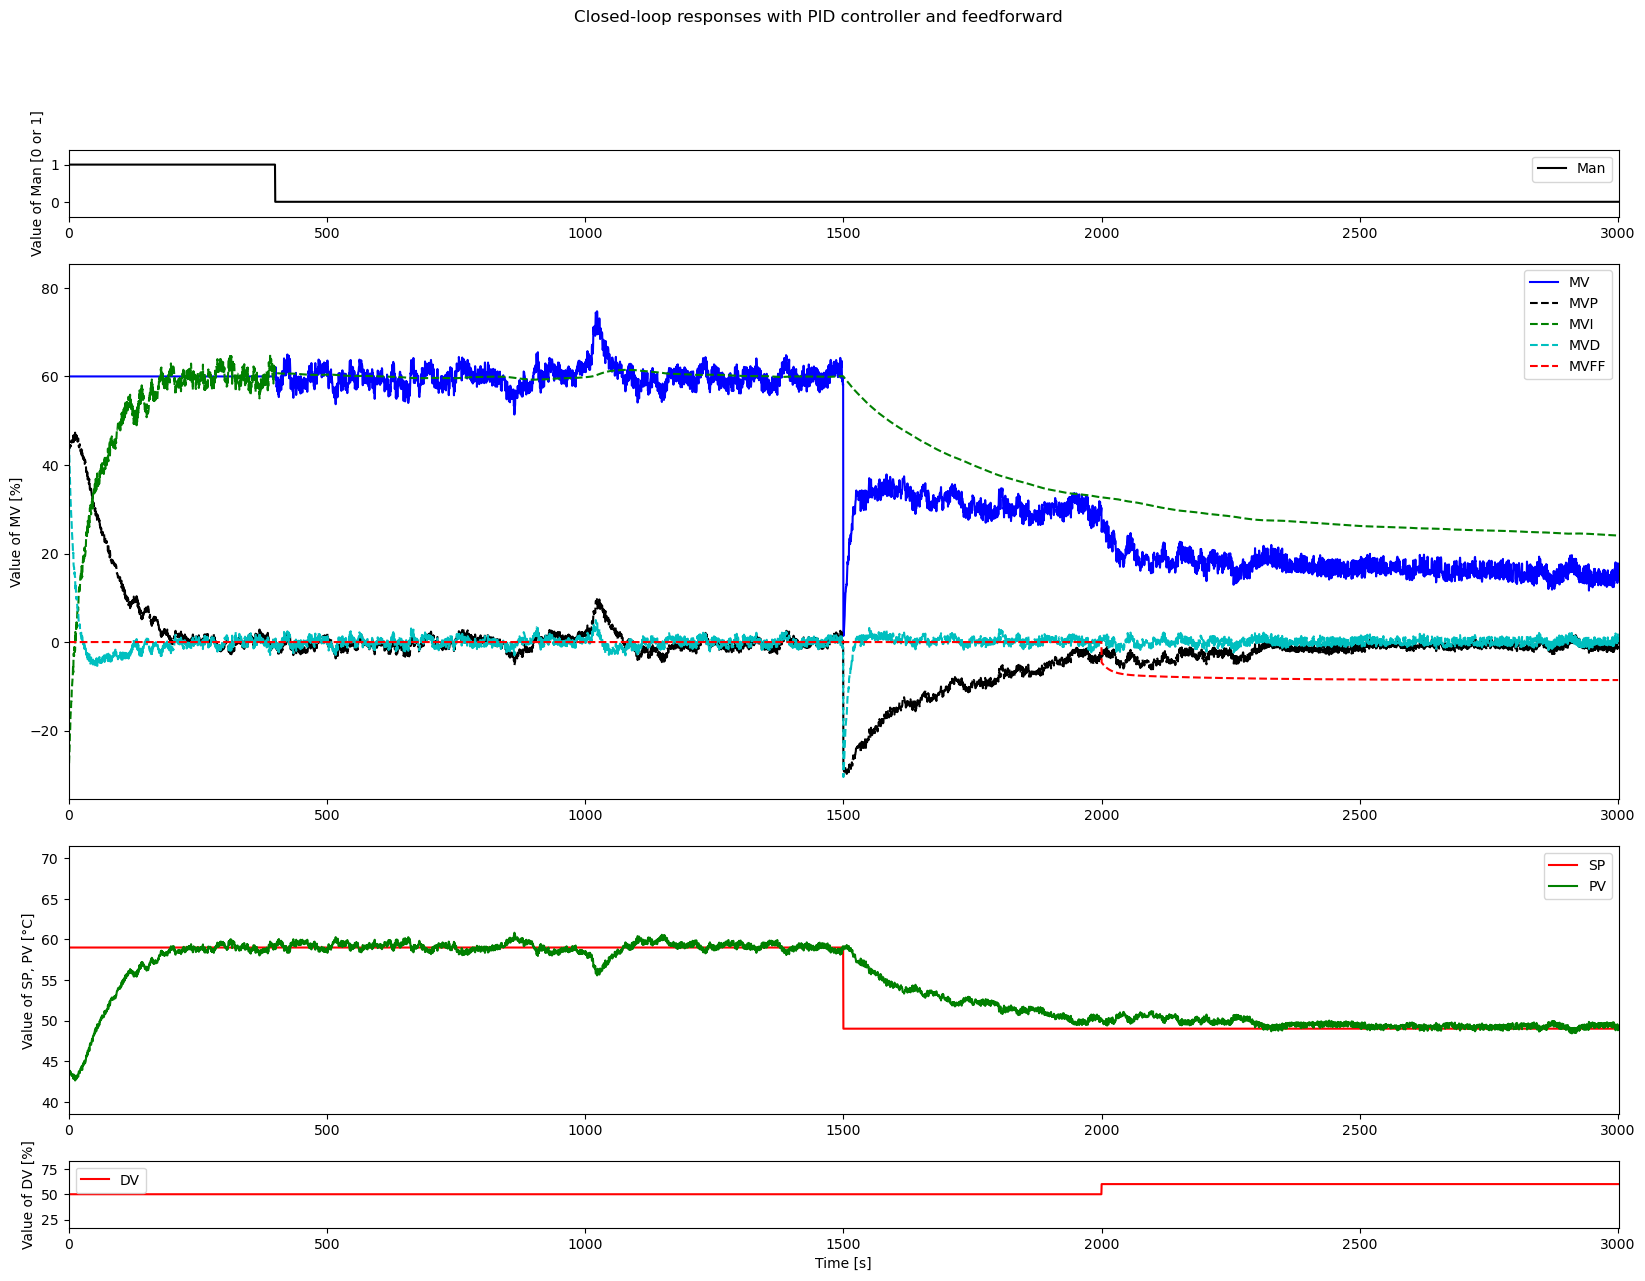

TCLab disconnected successfully.


In [ ]:
for i in range(0,N):
    t.append(i*Ts)

    if t[-1] == 0: #Quand on initialise donc qu'il n'y a encore rien dans le temps, on initialise la valeur de last_time
        last_time = time.time()


    PV.append(lab.T1) #On récupère la dernière valeur de température pour la mettre dans PV
    
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(MANPath,t,MAN) 
    SelectPath_RT(MVMANPath,t,MVMAN) 
    
    lab.Q2(DV[-1]) #On applique DV sur le heater 2 de la plateforme

    #FF
    Delay_RT(DV - DV0*np.ones_like(DV), np.max([theta_d-theta_p,0]),Ts,MVFFDelay)
    LL_RT(MVFFDelay,-Kd/Kp,Tlag1,TLead1,Ts,PV1)

    if StateFF:
        LL_RT(PV1,1,Tlag2,TLead2,Ts,MVFF)
    else:
        LL_RT(PV1,0,Tlag2,TLead2,Ts,MVFF)       

    

    PID_RT(SP, PV,MAN,MVMAN, MVFF, Kc_IMC, Ti_IMC, Td_IMC, alpha_IMC, Ts, MVMin, MVMAx, MV, MVP, MVI, MVD, E, ManFF, PV0)

    lab.Q1(MV[-1]) #On applique le MV sur le heater 1 de la plateforme


    now = time.time()
    delta = now - last_time

    time.sleep(np.max([0, Ts - delta]))
    last_time = time.time()

    clear_output(wait=True)

    l1.set_data(t,MAN)

    l2.set_data(t,MV)
    l3.set_data(t,MVP)
    l4.set_data(t,MVI)
    l5.set_data(t,MVD)
    l6.set_data(t,MVFF)

    l7.set_data(t,SP)
    l8.set_data(t,PV)

    l9.set_data(t,DV)
    

    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)


    display(fig)

lab.close()

In [ ]:
# Save data    
t = np.array(t) 
MV = np.array(MV)
PV = np.array(PV)
DV = np.array(DV)
MVI = np.array(MVI)
MVD = np.array(MVD)
MVP = np.array(MVP)
MVFF = np.array(MVFF)
SP = np.array(SP)
MAN = np.array(MAN)
my_data = np.vstack((t.T,MV.T,PV.T,DV.T,SP.T,MVI.T,MVP.T,MVD.T,MVFF.T,MAN.T))
my_data = my_data.T
nameFile = 'Data/Closed_loop_experiment_PID_FF_' + date_time + '.txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile,my_data,delimiter=',',header='t,MV,PV,DV,SP,MVI,MVP,MVD,MVFF,MAN',comments='')   

if not os.path.exists('Plots'):
    os.makedirs('Plots')

titleName = 'RT_CLP_PID_FF_' + date_time
plt.savefig('Plots\\' + titleName + '.png')
plt.savefig('Plots\\' + titleName + '.pdf')

NameError: name 'date_time' is not defined

# Other graph


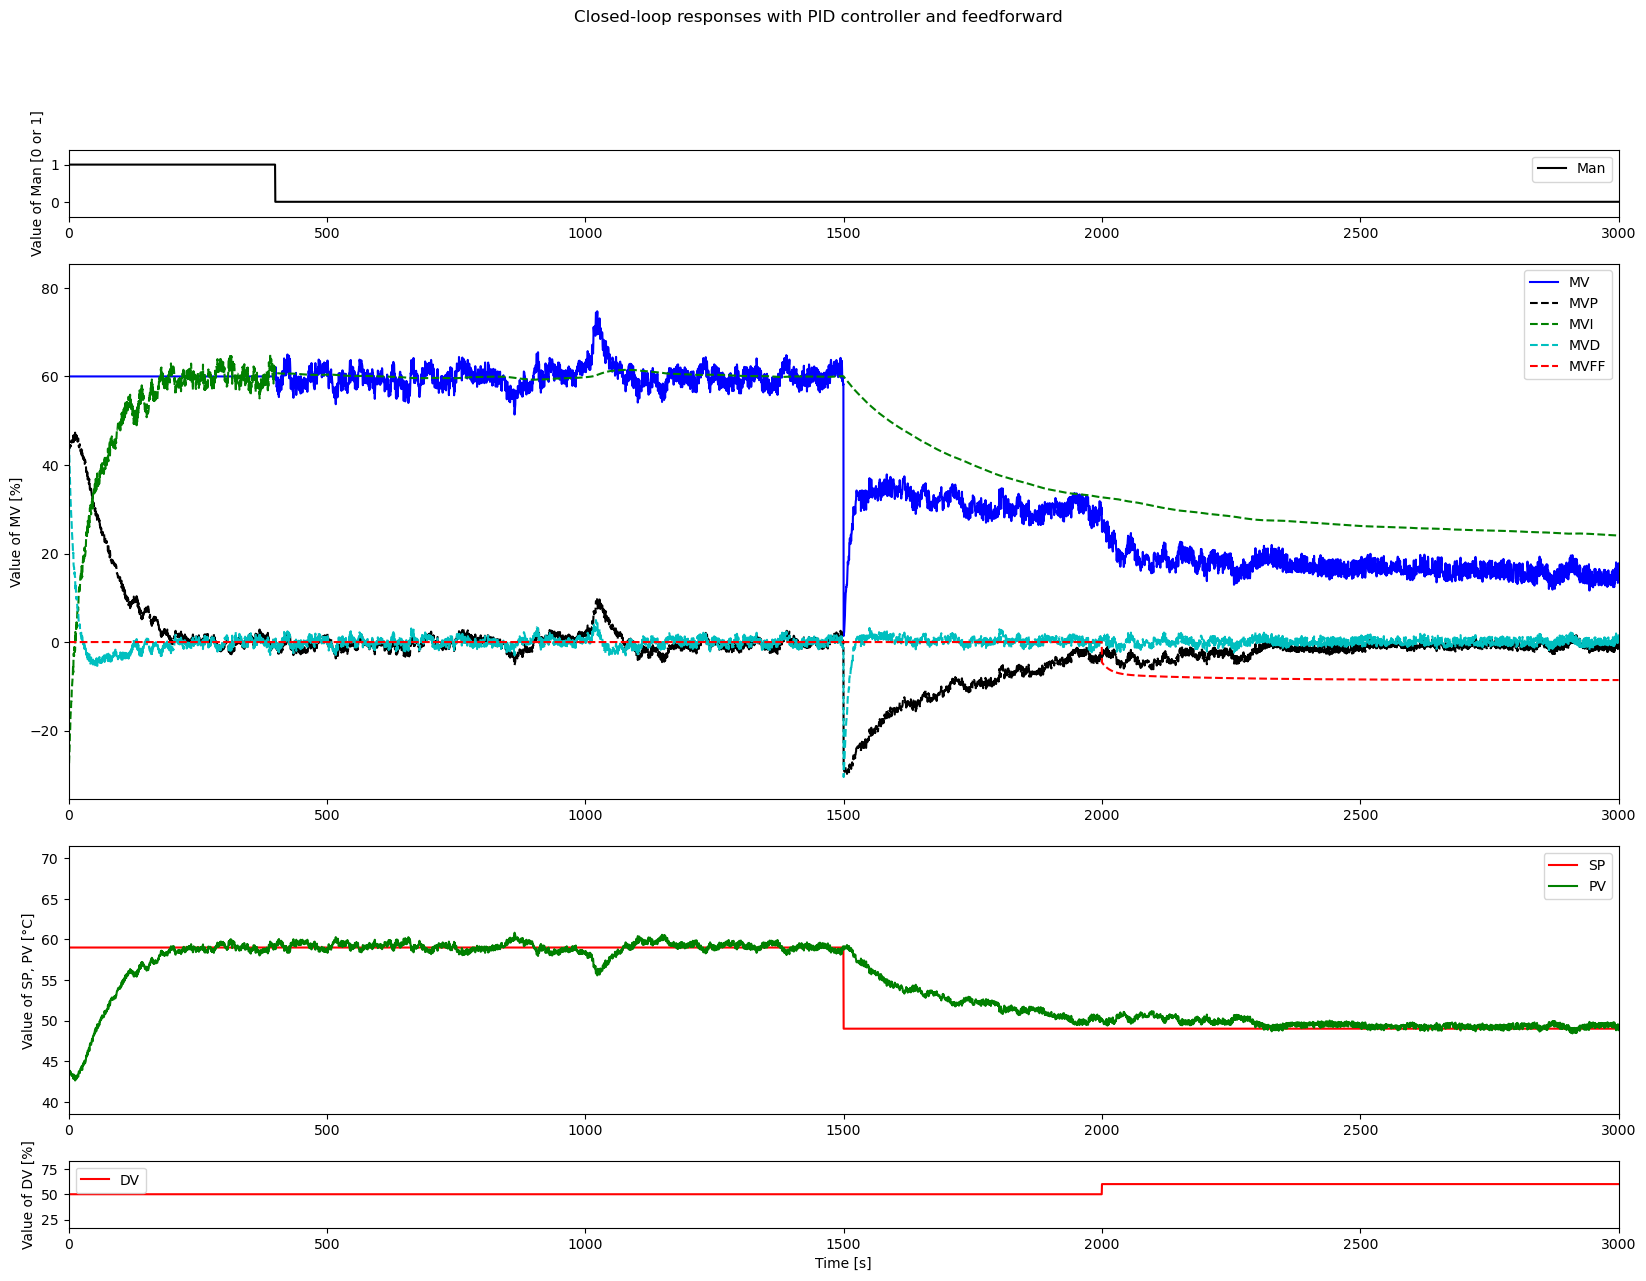

In [25]:
nameFile = 'Closed_loop_experiment_PID_FF_2026-03-25-11h08.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)


t = data['t'].values - data['t'].values[0]
MV = data['MV'].values
PV = data['PV'].values
DV = data['DV'].values
MVI = data['MVI'].values
MVD = data['MVD'].values
MVP = data['MVP'].values
MVFF = data['MVFF'].values
SP = data['SP'].values
MAN = data['MAN'].values

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4, 1,figsize=(20, 14), gridspec_kw={'height_ratios': [1, 8, 4,1]})
fig.suptitle('Closed-loop responses with PID controller and feedforward')

#Manual Mode
MAN_int = [1 if m else 0 for m in MAN]
l1, = ax1.plot(t, MAN_int, 'k-', label='Man')
ax1.set_ylabel('Value of Man [0 or 1]')
ax1.set_ylim([-0.4, 1.4])
ax1.legend(loc='upper right')
ax1.set_xlim([0, TSim])

#MV
l2, = ax2.plot([0,TSim], [-30,80],   'b-', label='MV')
l3, = ax2.plot([0,TSim], [-30,80],  'k--', label='MVP')
l4, = ax2.plot([0,TSim], [-30,80],  'g--', label='MVI')
l5, = ax2.plot([0,TSim], [-30,80],  'c--', label='MVD')
l6, = ax2.plot([0,TSim], [-30,80], 'r--', label='MVFF')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='upper right')
ax2.set_xlim([0, TSim])

# SP, PV
l7, = ax3.plot([0,TSim], [40,70], 'r-', label='SP')
l8, = ax3.plot([0,TSim], [40,70], 'g-', label='PV')
ax3.set_ylabel('Value of SP, PV [°C]')
ax3.legend(loc='upper right')
ax3.set_xlim([0, TSim])

# DV
l9, = ax4.plot([0,TSim], [20,80], 'r-', label='DV')
ax4.set_ylabel('Value of DV [%]')
ax4.set_xlabel('Time [s]')
ax4.legend(loc='upper left')
ax4.set_xlim([0, TSim])



l1.set_data(t,MAN)

l2.set_data(t,MV)
l3.set_data(t,MVP)
l4.set_data(t,MVI)
l5.set_data(t,MVD)
l6.set_data(t,MVFF)

l7.set_data(t,SP)
l8.set_data(t,PV)

l9.set_data(t,DV)


plt.show()
